STEP 0 — Import Required Libraries

In [1]:
# ============================================================
# STEP 0: IMPORTS
# ============================================================
import os
import cv2
import torch
import librosa
import subprocess
import tempfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mediapipe as mp

from tqdm import tqdm
from torch import nn
from torchvision import models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score
)
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


STEP 1 — Configuration Constants

In [2]:
# ============================================================
# STEP 1: CONSTANTS (must match training config)
# ============================================================
AUDIO_SR   = 16000
AUDIO_LEN  = 4.0
N_MFCC     = 40
N_MELS     = 64
TARGET_T   = 126
NUM_FRAMES = 16
IMG_SIZE   = 112
BATCH_SIZE = 4

STEP 2: MODEL ARCHITECTURE

In [3]:
# ============================================================
# STEP 2: REBUILD EXACT SAME MODEL ARCHITECTURE
# ============================================================
class AudioNet(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        def audio_cnn():
            return nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1))
            )
        self.mfcc_net = audio_cnn()
        self.mel_net  = audio_cnn()
        self.fc = nn.Linear(64 * 2, emb_dim)

    def forward(self, mfcc, mel):
        mfcc_feat = self.mfcc_net(mfcc).squeeze(-1).squeeze(-1)
        mel_feat  = self.mel_net(mel).squeeze(-1).squeeze(-1)
        if mfcc_feat.dim() == 1:
            mfcc_feat = mfcc_feat.unsqueeze(0)
        if mel_feat.dim() == 1:
            mel_feat = mel_feat.unsqueeze(0)
        x = torch.cat([mfcc_feat, mel_feat], dim=1)
        return self.fc(x)


class VideoNet(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Linear(512, emb_dim)

    def forward(self, frames):
        B, T, C, H, W = frames.shape
        frames = frames.view(B * T, C, H, W)
        feats  = self.backbone(frames)
        feats  = feats.view(B, T, 512).mean(dim=1)
        return self.fc(feats)


class AVFusionNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.audio_net = AudioNet()
        self.video_net = VideoNet()
        self.fusion = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, mfcc, mel, frames):
        audio_feat = self.audio_net(mfcc, mel)
        video_feat = self.video_net(frames)
        fused = torch.cat([audio_feat, video_feat], dim=1)
        return self.fusion(fused)


def load_trained_model(model_path="new_best_big_av_model.pth"):
    model = AVFusionNet(num_classes=4).to(device)
    model.load_state_dict(
        torch.load(model_path, map_location=device, weights_only=False)
    )
    model.eval()
    print(f"Model loaded from: {model_path}")
    return model

STEP 3: AUDIO + VIDEO FEATURE EXTRACTION

In [4]:
# ============================================================
# STEP 3: AUDIO + VIDEO FEATURE EXTRACTION (same as training)
# ============================================================
mp_face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)
LIP_LANDMARKS = list(range(61, 88))


def get_lip_bbox(landmarks, img_w, img_h, margin=0.3):
    xs = [landmarks[i].x for i in LIP_LANDMARKS]
    ys = [landmarks[i].y for i in LIP_LANDMARKS]
    cx, cy = np.mean(xs), np.mean(ys)
    size = max(max(xs) - min(xs), max(ys) - min(ys)) * (1 + margin)
    x1 = int((cx - size / 2) * img_w)
    x2 = int((cx + size / 2) * img_w)
    y1 = int((cy - size / 2) * img_h)
    y2 = int((cy + size / 2) * img_h)
    return max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)


def load_audio_from_video(video_path):
    try:
        tmp_wav = tempfile.mktemp(suffix=".wav")
        cmd = ["ffmpeg", "-y", "-i", video_path, "-vn", "-ac", "1",
               "-ar", str(AUDIO_SR), tmp_wav]
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        y, _ = librosa.load(tmp_wav, sr=AUDIO_SR, duration=AUDIO_LEN)
        os.remove(tmp_wav)
        return y.astype(np.float32)
    except Exception:
        return np.zeros(int(AUDIO_SR * AUDIO_LEN), dtype=np.float32)


def pad_or_trim(feat, target_T):
    if feat.shape[1] < target_T:
        pad = target_T - feat.shape[1]
        feat = np.pad(feat, ((0, 0), (0, pad)))
    else:
        feat = feat[:, :target_T]
    return feat


def extract_audio_features(waveform):
    mfcc = librosa.feature.mfcc(y=waveform, sr=AUDIO_SR, n_mfcc=N_MFCC)
    mel  = librosa.feature.melspectrogram(y=waveform, sr=AUDIO_SR, n_mels=N_MELS)
    mel  = librosa.power_to_db(mel, ref=np.max)
    mfcc = pad_or_trim(mfcc, TARGET_T)
    mel  = pad_or_trim(mel, TARGET_T)
    mfcc = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)
    mel  = torch.tensor(mel,  dtype=torch.float32).unsqueeze(0)
    return mfcc, mel

STEP 4: VIDEO FRAME EXTRACTION

In [5]:
def extract_lip_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return torch.zeros(NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE)
    frame_indices = np.linspace(0, total_frames - 1, NUM_FRAMES, dtype=int)
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        h, w = frame.shape[:2]
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = mp_face_mesh.process(rgb)
        if result.multi_face_landmarks:
            lm = result.multi_face_landmarks[0].landmark
            x1, y1, x2, y2 = get_lip_bbox(lm, w, h)
            frame = frame[y1:y2, x1:x2]
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = frame.astype(np.float32) / 255.0
        frame = torch.tensor(frame).permute(2, 0, 1)
        frames.append(frame)
    cap.release()
    if len(frames) == 0:
        return torch.zeros(NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE)
    while len(frames) < NUM_FRAMES:
        frames.append(frames[-1])
    return torch.stack(frames[:NUM_FRAMES])

STEP 5: GENERIC CROSS-DATASET DATASET CLASS

In [6]:
# ============================================================
# STEP 4: GENERIC CROSS-DATASET DATASET CLASS
# ============================================================
class CrossDataset(Dataset):
    """
    Generic dataset for any external dataset.
    Expects a DataFrame with columns: ['video_path', 'label']
    label: 0 = real, 1 = fake  (binary)
    """
    def __init__(self, df):
        self.video_paths = df["video_path"].tolist()
        self.labels      = df["label"].tolist()

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label      = self.labels[idx]
        waveform   = load_audio_from_video(video_path)
        mfcc, logmel = extract_audio_features(waveform)
        frames     = extract_lip_frames(video_path)
        return mfcc, logmel, frames, torch.tensor(label, dtype=torch.long)

STEP 6: DATASET LOADERS

6A — DFDC Loader

In [7]:
# ------ 5A. DFDC ------
def load_dfdc_df(dfdc_root, labels_csv):
    """
    dfdc_root : path to DFDC dataset root
    labels_csv: path to labels.csv with columns [filename, label]
                label: REAL=0, FAKE=1

    DFDC Download:
    https://ai.meta.com/datasets/dfdc/
    Structure expected:
      dfdc_root/
        videos/
          *.mp4
        labels.csv  (filename, label)
    """
    df = pd.read_csv(labels_csv)
    df["video_path"] = df["filename"].apply(
        lambda x: os.path.join(dfdc_root, "videos", x)
    )
    df = df[df["video_path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"DFDC: {len(df)} valid videos | Real: {(df.label==0).sum()} | Fake: {(df.label==1).sum()}")
    return df

6B — FaceForensics++ Loader

In [8]:
# ------ 5B. FaceForensics++ ------
def load_ff_df(ff_root, compression="c23", num_real=500, num_fake=500):
    """
    ff_root     : path to FaceForensics++ dataset root
    compression : 'c0' (raw), 'c23' (low), 'c40' (high)

    FF++ Download:
    https://github.com/ondyari/FaceForensics
    Structure expected:
      ff_root/
        original_sequences/youtube/c23/videos/*.mp4   (real)
        manipulated_sequences/Deepfakes/c23/videos/*.mp4 (fake)
        manipulated_sequences/Face2Face/c23/videos/*.mp4
        manipulated_sequences/FaceSwap/c23/videos/*.mp4
        manipulated_sequences/NeuralTextures/c23/videos/*.mp4
    """
    rows = []
    real_dir = os.path.join(ff_root, "original_sequences", "youtube",
                            compression, "videos")
    fake_methods = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

    # Real videos
    if os.path.exists(real_dir):
        real_vids = [f for f in os.listdir(real_dir) if f.endswith(".mp4")][:num_real]
        for v in real_vids:
            rows.append({"video_path": os.path.join(real_dir, v), "label": 0, "method": "real"})

    # Fake videos
    for method in fake_methods:
        fake_dir = os.path.join(ff_root, "manipulated_sequences", method,
                                compression, "videos")
        if os.path.exists(fake_dir):
            fake_vids = [f for f in os.listdir(fake_dir) if f.endswith(".mp4")]
            per_method = num_fake // len(fake_methods)
            for v in fake_vids[:per_method]:
                rows.append({"video_path": os.path.join(fake_dir, v),
                             "label": 1, "method": method})

    df = pd.DataFrame(rows)
    df = df[df["video_path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"FF++: {len(df)} valid videos | Real: {(df.label==0).sum()} | Fake: {(df.label==1).sum()}")
    return df

6C — DeepFakeTIMIT Loader

In [9]:
# ------ 5C. DeepFakeTIMIT ------
def load_dftimit_df(dftimit_root, quality="higher_quality"):
    """
    Fixed for actual DeepFakeTIMIT structure:
      - Real videos: dftimit_root/*-original.mov  (root level)
      - Fake videos: dftimit_root/higher_quality/<speaker_id>/*.avi or *.mp4
    
    quality: "higher_quality" or "lower_quality"
    """
    rows = []

    # --- REAL videos: *-original.mov at root level ---
    for f in os.listdir(dftimit_root):
        if f.endswith("-original.mov"):
            rows.append({
                "video_path": os.path.join(dftimit_root, f),
                "label": 0   # real
            })

    # --- FAKE videos: inside higher_quality/<speaker>/ ---
    quality_dir = os.path.join(dftimit_root, quality)
    if os.path.exists(quality_dir):
        for speaker in os.listdir(quality_dir):
            speaker_dir = os.path.join(quality_dir, speaker)
            if not os.path.isdir(speaker_dir):
                continue
            for f in os.listdir(speaker_dir):
                if f.endswith((".mp4", ".avi", ".mov")):
                    rows.append({
                        "video_path": os.path.join(speaker_dir, f),
                        "label": 1   # fake
                    })

    # --- Build DataFrame safely ---
    if len(rows) == 0:
        print("ERROR: No videos found. Check your DFTIMIT_ROOT path.")
        return pd.DataFrame(columns=["video_path", "label"])

    df = pd.DataFrame(rows)
    df = df[df["video_path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"DeepFakeTIMIT ({quality}): {len(df)} videos | "
          f"Real: {(df.label==0).sum()} | Fake: {(df.label==1).sum()}")
    return df

6D - Celeb-DF (v2)

In [10]:
# STEP 6D: Celeb-DF (v2) Loader
def load_celebdf_v2_df(celebdf_root,limit=None):
    """
    celebdf_root: Path to Celeb-DF-v2 dataset root
    Structure expected:
    celebdf_root/
        Celeb-real/*.mp4 (Real)
        YouTube-real/*.mp4 (Real)
        Celeb-synthesis/*.mp4 (Fake)
    """
    rows = []
    # Real videos
    real_folders = ["Celeb-real", "YouTube-real"]
    for folder in real_folders:
        folder_path = os.path.join(celebdf_root, folder)
        if os.path.exists(folder_path):
            vids = [f for f in os.listdir(folder_path) if f.endswith(".mp4")]
            for v in vids:
                rows.append({"video_path": os.path.join(folder_path, v), "label": 0})
    
    # Fake videos
    fake_folder = os.path.join(celebdf_root, "Celeb-synthesis")
    if os.path.exists(fake_folder):
        vids = [f for f in os.listdir(fake_folder) if f.endswith(".mp4")]
        for v in vids:
            rows.append({"video_path": os.path.join(fake_folder, v), "label": 1})

    df = pd.DataFrame(rows)
    
    # Check if files actually exist
    df = df[df["video_path"].apply(os.path.exists)].reset_index(drop=True)

    # --- RANDOM SAMPLING LOGIC ---
    if limit and len(df) > limit:
        # random_state=42 ensures you get the same 'random' set every time you run it
        df = df.sample(n=limit, random_state=42).reset_index(drop=True)
        print(f"Subsampled to {limit} videos randomly.")
    
    if len(df) > 0:
        print(f"Final Celeb-DF (v2) Count: {len(df)} | Real: {(df.label==0).sum()} | Fake: {(df.label==1).sum()}")
    
    return df

STEP 7: EVALUATION FUNCTION

In [11]:
# ============================================================
# STEP 6: EVALUATION FUNCTION
# ============================================================
def evaluate_on_dataset(model, df, dataset_name, binary=True):
    """
    Runs inference on a dataset and returns metrics.
    binary=True  → maps FakeAVCeleb 4-class to binary (0=real, 1=fake)
    """
    print(f"\n{'='*60}")
    print(f"  Evaluating on: {dataset_name}")
    print(f"{'='*60}")

    dataset    = CrossDataset(df)
    loader     = DataLoader(dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0)

    y_true, y_pred, y_scores = [], [], []

    model.eval()
    with torch.no_grad():
        for mfcc, mel, frames, labels in tqdm(loader, desc=dataset_name, ncols=100):
            mfcc   = mfcc.to(device)
            mel    = mel.to(device)
            frames = frames.to(device)

            outputs = model(mfcc, mel, frames)
            probs   = torch.softmax(outputs, dim=1)

            if binary:
                fake_prob = probs[:, 1:].sum(dim=1)
                preds     = (fake_prob > 0.5).long()
                y_scores.extend(fake_prob.cpu().numpy())
            else:
                preds = outputs.argmax(dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true   = np.array(y_true)
    y_pred   = np.array(y_pred)
    y_scores = np.array(y_scores)

    acc   = accuracy_score(y_true, y_pred) * 100
    f1    = f1_score(y_true, y_pred, average="weighted") * 100
    try:
        auc = roc_auc_score(y_true, y_scores) * 100
    except Exception:
        auc = float("nan")

    print(f"\nResults — {dataset_name}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  F1-Score  : {f1:.2f}%")
    print(f"  AUC       : {auc:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=["Real", "Fake"] if binary else None))

    return {"dataset": dataset_name, "accuracy": acc, "f1": f1, "auc": auc,
            "y_true": y_true, "y_pred": y_pred}

STEP 8: CONFUSION MATRIX PLOT

In [12]:
# ============================================================
# STEP 7: CONFUSION MATRIX PLOT
# ============================================================
def plot_confusion(results, binary=True):
    labels = ["Real", "Fake"] if binary else ["RV-RA", "FV-RA", "RV-FA", "FV-FA"]
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, res in zip(axes, results):
        cm = confusion_matrix(res["y_true"], res["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_title(f"{res['dataset']}\nAcc={res['accuracy']:.1f}% AUC={res['auc']:.1f}%")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()


STEP 9: PERFORMANCE DROP ANALYSIS

In [13]:
# ============================================================
# STEP 8: PERFORMANCE DROP ANALYSIS
# ============================================================
def performance_drop_report(fakeavceleb_acc, results):
    """
    Prints the cross-dataset drop table expected in a paper.
    fakeavceleb_acc: float, e.g. 98.04
    """
    print("\n" + "=" * 65)
    print("  CROSS-DATASET GENERALIZATION REPORT")
    print("=" * 65)
    print(f"  {'Dataset':<25} {'Accuracy':>10} {'F1':>10} {'AUC':>10} {'Drop':>10}")
    print("-" * 65)
    print(f"  {'FakeAVCeleb (source)':<25} {fakeavceleb_acc:>9.2f}%"
          f" {'—':>10} {'—':>10} {'—':>10}")
    for res in results:
        drop = fakeavceleb_acc - res["accuracy"]
        print(f"  {res['dataset']:<25} {res['accuracy']:>9.2f}%"
              f" {res['f1']:>9.2f}% {res['auc']:>9.2f}% {drop:>+9.2f}%")
    print("=" * 65)

    avg_drop = np.mean([fakeavceleb_acc - r["accuracy"] for r in results])
    print(f"\n  Average cross-dataset drop: {avg_drop:.2f}%")
    print(f"\n  Paper statement:")
    print(f"  'Cross-dataset evaluation revealed an average performance")
    print(f"   drop of {avg_drop:.1f}%, highlighting domain shift challenges")
    print(f"   and the need for generalizable multimodal representations.'")
    return avg_drop

STEP 10: BAR CHART — CROSS-DATASET COMPARISON

In [14]:
# ============================================================
# STEP 9: BAR CHART — CROSS-DATASET COMPARISON
# ============================================================
def plot_comparison_bar(fakeavceleb_acc, results):
    datasets  = ["FakeAVCeleb"] + [r["dataset"] for r in results]
    accs      = [fakeavceleb_acc] + [r["accuracy"] for r in results]
    colors    = ["#2196F3"] + ["#FF5722"] * len(results)

    plt.figure(figsize=(9, 5))
    bars = plt.bar(datasets, accs, color=colors, edgecolor="black", width=0.5)
    for bar, acc in zip(bars, accs):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5, f"{acc:.1f}%",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
    plt.axhline(y=fakeavceleb_acc, color="#2196F3", linestyle="--",
                alpha=0.6, label=f"Source accuracy ({fakeavceleb_acc:.1f}%)")
    plt.ylim(0, 110)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.title("Cross-Dataset Generalization", fontsize=14, fontweight="bold")
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


STEP 11: MAIN

Model loaded from: new_best_big_av_model.pth
DFDC not found — skipping. Set DFDC_ROOT above.
FaceForensics++ not found — skipping. Set FF_ROOT above.
DeepFakeTIMIT (higher_quality): 322 videos | Real: 2 | Fake: 320

  Evaluating on: DeepFakeTIMIT


DeepFakeTIMIT: 100%|████████████████████████████████████████████████| 81/81 [05:30<00:00,  4.07s/it]
D:\Software\Anaconda3\envs\deepfake\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Software\Anaconda3\envs\deepfake\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Software\Anaconda3\envs\deepfake\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramet


Results — DeepFakeTIMIT
  Accuracy  : 99.38%
  F1-Score  : 99.07%
  AUC       : 96.09%

Classification Report:
              precision    recall  f1-score   support

        Real       0.00      0.00      0.00         2
        Fake       0.99      1.00      1.00       320

    accuracy                           0.99       322
   macro avg       0.50      0.50      0.50       322
weighted avg       0.99      0.99      0.99       322

Subsampled to 300 videos randomly.
Final Celeb-DF (v2) Count: 300 | Real: 41 | Fake: 259

  Evaluating on: Celeb-DF (v2)


C:\Users\LEGION\AppData\Local\Temp\ipykernel_14292\3741649697.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(tmp_wav, sr=AUDIO_SR, duration=AUDIO_LEN)
D:\Software\Anaconda3\envs\deepfake\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Celeb-DF (v2): 100%|████████████████████████████████████████████████| 75/75 [03:30<00:00,  2.80s/it]



Results — Celeb-DF (v2)
  Accuracy  : 69.00%
  F1-Score  : 73.02%
  AUC       : 62.66%

Classification Report:
              precision    recall  f1-score   support

        Real       0.20      0.41      0.27        41
        Fake       0.89      0.73      0.80       259

    accuracy                           0.69       300
   macro avg       0.54      0.57      0.54       300
weighted avg       0.79      0.69      0.73       300



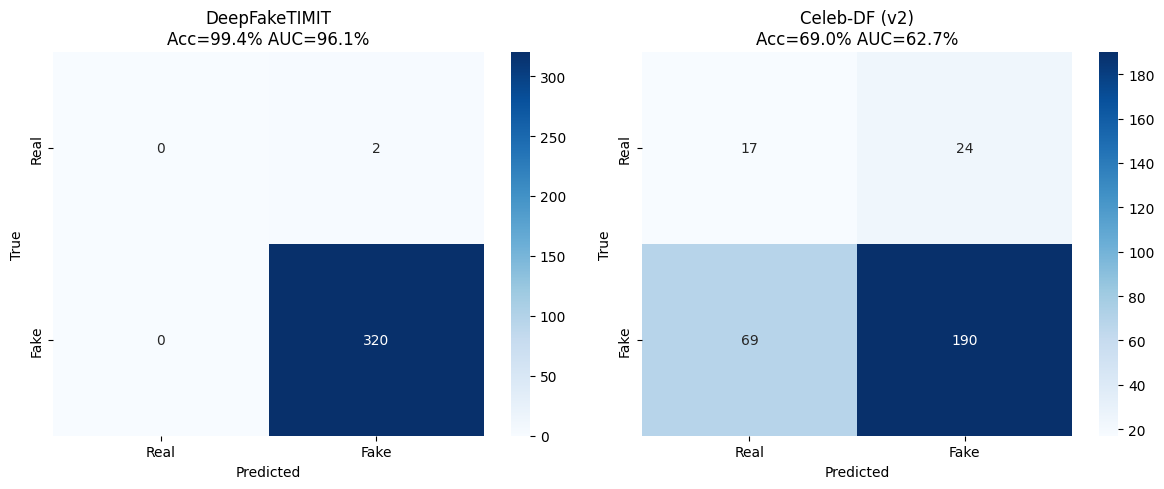

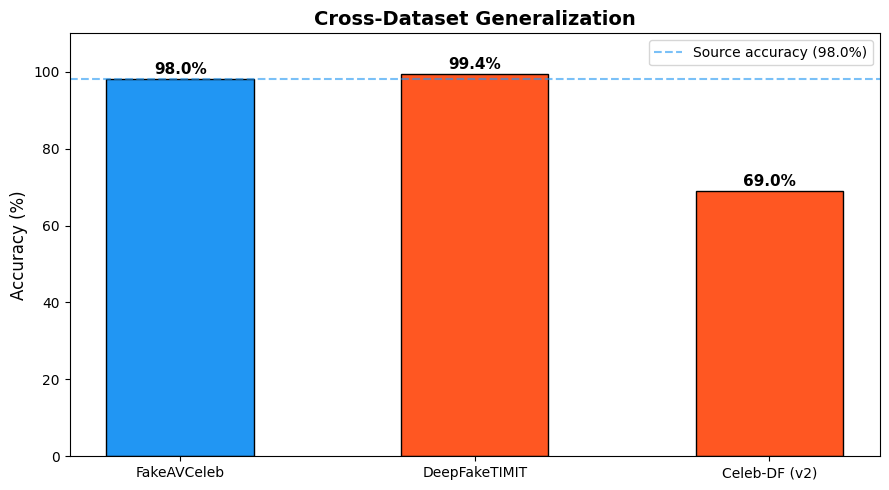


  CROSS-DATASET GENERALIZATION REPORT
  Dataset                     Accuracy         F1        AUC       Drop
-----------------------------------------------------------------
  FakeAVCeleb (source)          98.04%          —          —          —
  DeepFakeTIMIT                 99.38%     99.07%     96.09%     -1.34%
  Celeb-DF (v2)                 69.00%     73.02%     62.66%    +29.04%

  Average cross-dataset drop: 13.85%

  Paper statement:
  'Cross-dataset evaluation revealed an average performance
   drop of 13.9%, highlighting domain shift challenges
   and the need for generalizable multimodal representations.'


In [15]:
# ============================================================
# STEP 10: MAIN — RUN EVERYTHING
# ============================================================
if __name__ == "__main__":

    # --- Load model ---
    MODEL_PATH = "new_best_big_av_model.pth"
    model = load_trained_model(MODEL_PATH)

    # ----------------------------------------------------------------
    # SET YOUR DATASET PATHS HERE
    # ----------------------------------------------------------------
    DFDC_ROOT      = "./datasets/DFDC"               
    DFDC_LABELS    = "./datasets/DFDC/labels.csv"    
    FF_ROOT        = "./datasets/FaceForensics++"    
    DFTIMIT_ROOT   = "./DeepFakeTIMIT"
    CELEBDF_ROOT   = "./CelebDF_v2"
    # ----------------------------------------------------------------

    FAKEAVCELEB_ACC = 98.04

    all_results = []

    # ---- DFDC ----
    if os.path.exists(DFDC_ROOT):
        dfdc_df = load_dfdc_df(DFDC_ROOT, DFDC_LABELS)
        res = evaluate_on_dataset(model, dfdc_df, "DFDC", binary=True)
        all_results.append(res)
    else:
        print("DFDC not found — skipping. Set DFDC_ROOT above.")

    # ---- FF++ ----
    if os.path.exists(FF_ROOT):
        ff_df = load_ff_df(FF_ROOT, compression="c23", num_real=500, num_fake=500)
        res = evaluate_on_dataset(model, ff_df, "FaceForensics++", binary=True)
        all_results.append(res)
    else:
        print("FaceForensics++ not found — skipping. Set FF_ROOT above.")

    # ---- DeepFakeTIMIT ----
    if os.path.exists(DFTIMIT_ROOT):
        timit_df = load_dftimit_df(DFTIMIT_ROOT)
        res = evaluate_on_dataset(model, timit_df, "DeepFakeTIMIT", binary=True)
        all_results.append(res)
    else:
        print("DeepFakeTIMIT not found — skipping. Set DFTIMIT_ROOT above.")

    # ---- Celeb-DF (v2) ----
    if os.path.exists(CELEBDF_ROOT):
        # This will take 300 random videos from the total dataset
        celebdf_df = load_celebdf_v2_df(CELEBDF_ROOT, limit=300)
        
        # Pass this sampled dataframe to your evaluation function
        res = evaluate_on_dataset(model, celebdf_df, "Celeb-DF (v2)", binary=True)
        all_results.append(res)
    else:
        print("Celeb-DF (v2) not found skipping. Set CELEBDF_ROOT above.").

    # ---- Plots & Report ----
    if all_results:
        plot_confusion(all_results, binary=True)
        plot_comparison_bar(FAKEAVCELEB_ACC, all_results)
        avg_drop = performance_drop_report(FAKEAVCELEB_ACC, all_results)
    else:
        print("\nNo external datasets found. Please set dataset paths above.")

STEP 12: SINGLE VIDEO PREDICTION UTILITY

In [16]:
# ============================================================
# QUICK TEST: Evaluate a single video file
# ============================================================
def predict_single_video(video_path, model):
    """
    Utility: run inference on a single video.
    Returns: predicted label (0=Real, 1=Fake) + confidence
    """
    model.eval()
    wav  = load_audio_from_video(video_path)
    mfcc, mel = extract_audio_features(wav)
    frames    = extract_lip_frames(video_path)

    mfcc   = mfcc.unsqueeze(0).to(device)
    mel    = mel.unsqueeze(0).to(device)
    frames = frames.unsqueeze(0).to(device)

    with torch.no_grad():
        out   = model(mfcc, mel, frames)
        probs = torch.softmax(out, dim=1).squeeze()
        fake_prob = probs[1:].sum().item()
        pred      = "FAKE" if fake_prob > 0.5 else "REAL"

    print(f"\nVideo: {os.path.basename(video_path)}")
    print(f"  Prediction  : {pred}")
    print(f"  Fake Prob   : {fake_prob:.4f}")
    print(f"  Real Prob   : {1 - fake_prob:.4f}")
    return pred, fake_prob


# Example usage (uncomment):
# model = load_trained_model("new_best_big_av_model.pth")
# predict_single_video("path/to/any_video.mp4", model)